# Figure 2 - Multilayer learning: Backprop vs Hebb

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs
import h5py

import EIANN.utils as ut
import EIANN.plot as pt
from EIANN.generate_figures import *

pt.update_plot_defaults()
root_dir = ut.get_project_root()

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
figure_name = "Fig2_vanBP_bpDale_hebb"
model_list = ["vanBP", "bpDale_learned", "HebbWN_topsup"]
model_dict_all = load_model_dict()
generate_hdf5_all_seeds(model_list, model_dict_all, recompute=None)

Generating plots for Backprop (ANN)
Generating plots for Backprop (EIANN)
Generating plots for Hebb (EIANN)


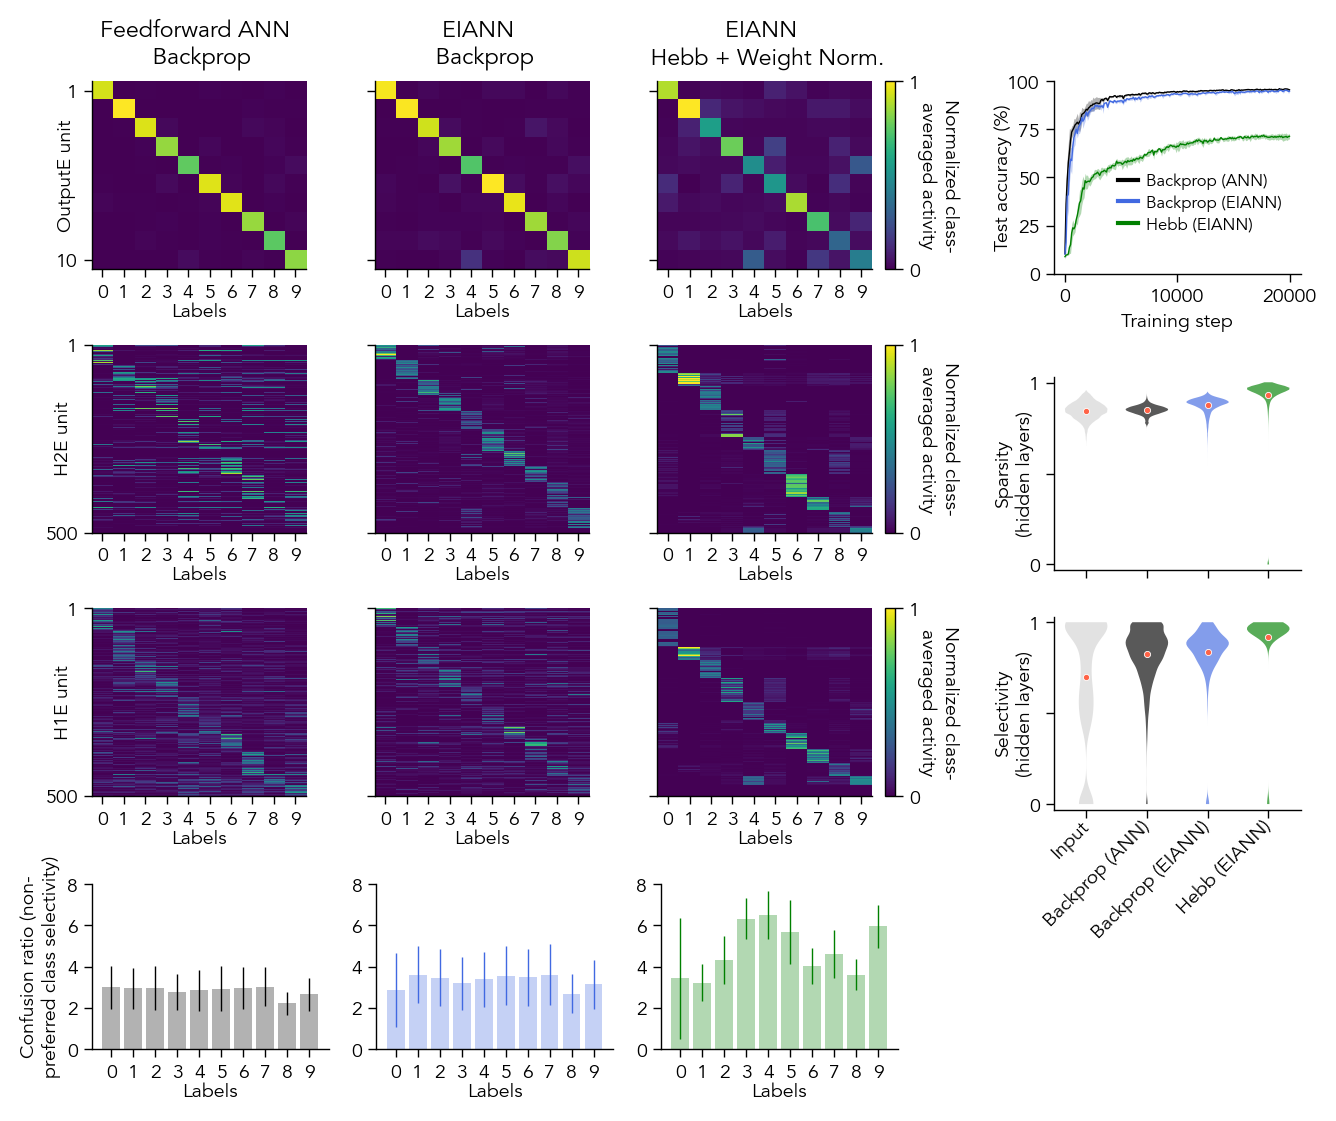

In [14]:
fig = plt.figure(figsize=(6.5, 5.5))
axes = gs.GridSpec(nrows=3, ncols=len(model_list), figure=fig,                    
                    left=0.06,right=0.66, top=0.93, bottom=0.28,
                    wspace=0.32, hspace=0.4)

axes_bargraphs = gs.GridSpec(nrows=1, ncols=len(model_list), figure=fig,      
                    left=0.06,right=0.68, top=0.2, bottom=0.05,
                    wspace=0.2)

axes_metrics = gs.GridSpec(nrows=5, ncols=1, figure=fig,
                    left=0.8,right=0.99, top=0.93, bottom=0.05,
                    wspace=0.8, hspace=0.3, height_ratios=[1, 0.05, 1, 1, 1])

ax_accuracy    = fig.add_subplot(axes_metrics[0])  
ax_sparsity   = fig.add_subplot(axes_metrics[2])
ax_selectivity = fig.add_subplot(axes_metrics[3])
root_dir = ut.get_project_root()

model_dict_all["vanBP"]["display_name"] = "Feedforward ANN \n Backprop"
model_dict_all["bpDale_learned"]["display_name"] = "EIANN \n Backprop"
model_dict_all["HebbWN_topsup"]["display_name"] = "EIANN \n Hebb + Weight Norm."

for col, model_key in enumerate(model_list):
    model_dict = model_dict_all[model_key]
    network_name = model_dict['config'].split('.')[0]
    hdf5_path = root_dir + f"/EIANN/data/model_hdf5_plot_data/plot_data_{network_name}.h5"
    with h5py.File(hdf5_path, 'r') as f:
        data_dict = f[network_name]
        print(f"Generating plots for {model_dict['label']}")

        #########################################################
        # Example heatmaps for E populations
        #########################################################
        example_seed = model_dict['seeds'][0]
        for row, population in enumerate(['OutputE','H2E','H1E']):
            # Activity plots: batch accuracy of each population to the test dataset
            ax = fig.add_subplot(axes[row, col])
            average_pop_activity_dict = data_dict[example_seed]['average_pop_activity_dict']
            num_units = average_pop_activity_dict[population].shape[1]
            pt.plot_batch_accuracy_from_data(average_pop_activity_dict, population=population, sort=True, ax=ax, cbar=False)    
            ax.set_yticks([0,num_units-1])
            ax.set_yticklabels([1,num_units])
            if col == 0:
                ax.set_ylabel(f'{population} unit', labelpad=-7 if row==0 else -10)
            else:
                ax.set_yticklabels([])
                ax.set_ylabel('')
                if col==len(model_list)-1:
                    pos = ax.get_position()                
                    cbar_ax = fig.add_axes([pos.x1 + 0.01, pos.y0, 0.008, pos.height])                
                    cbar = matplotlib.colorbar.ColorbarBase(cbar_ax, cmap='viridis', orientation='vertical')
                    cbar.set_label('Normalized class-\naveraged activity', labelpad=14, rotation=270)
                    cbar.set_ticks([0, 1])
            if row == 0:
                ax.set_title(model_dict["display_name"])
            ax.set_xlabel(ax.get_xlabel(), labelpad=0)

        ###############################
        # Class confusion bar graphs
        ###############################
        ax = fig.add_subplot(axes_bargraphs[0, col])
        plot_confusion_all_seeds(data_dict, model_dict, ax=ax)
        if col>0:
            ax.set_ylabel('')

        #################
        # Plot metrics
        #################
        plot_accuracy_all_seeds(data_dict, model_dict, ax=ax_accuracy, legend=True)

        populations_to_plot = ['H1E', 'H2E']
        plot_metric_all_seeds(data_dict, model_dict, populations_to_plot=populations_to_plot, ax=ax_sparsity, metric_name='sparsity', plot_type='violin', side='both')
        plot_metric_all_seeds(data_dict, model_dict, populations_to_plot=populations_to_plot, ax=ax_selectivity, metric_name='selectivity', plot_type='violin', side='both')
        ax_sparsity.set_ylabel(f"Sparsity\n(hidden layers)", labelpad=-2)
        ax_selectivity.set_ylabel(f"Selectivity\n(hidden layers)", labelpad=-2)
        ax_sparsity.set_xticklabels([])

fig.savefig(f"{root_dir}/EIANN/figures/{figure_name}.svg", dpi=300)
fig.savefig(f"{root_dir}/EIANN/figures/{figure_name}.png", dpi=300)

# Supplementary Figure

In [4]:
# figure_name = "Fig2_supplementary"
# model_list = ["vanBP", "bpDale_learned", "bpDale_fixed", "HebbWN_topsup", "bpLike_WT_hebbdend"]
# model_dict_all = load_model_dict()
# generate_hdf5_all_seeds(model_list, model_dict_all, recompute=None)